### 1. Introduction

#### 1. 5 examples of the application of ML methods in life

1. Email spam detection – filters unwanted messages automatically (classification).

2. Movie recommendation systems – suggest movies based on user preferences (recommendation).

3. Credit scoring – predicts the probability of loan default (classification/regression).

4. Self-driving cars – detect objects and make driving decisions (computer vision).

5. Medical diagnosis – predicts diseases from medical data (classification).

#### 2. Use the classification of tasks in the introduction to decide which class you can assign to the tasks from the table above and to the 5 examples you provided
1. Spam detection → Classification

2. Movie recommendation → Clustering

3. Credit scoring → Classification, Regression

4. Self-driving cars → Classification

5. Medical diagnosis → Classification

#### 3. Think about what the difference is between multiclass and multilabel(Разница между multiclass и multilabel)
Multiclass: each sample belongs to only one class (e.g., type of animal: cat, dog, bird).

Multilabel: each sample can belong to multiple classes at once (e.g., a photo with both “dog” and “person”).

Мультиклассовая (multiclass): каждый объект относится только к одному классу (например, кошка, собака или птица).

Мультилейбловая (multilabel): один объект может относиться к нескольким классам одновременно (например, на фото есть и человек, и собака).

#### 4. Is an example case with house prices from the theory a classification of a regression problem? Is it possible to reduce the regression problem to classification? (Является ли пример с ценами на жильё из теории классификацией задачи регрессии? Можно ли свести задачу регрессии к классификации?)

Predicting house prices is a regression problem because the target variable (price) is continuous.
It can be reduced to a classification problem by dividing prices into categories (e.g., low, medium, high).

Прогнозирование цен на жильё — это задача регрессии, потому что целевая переменная (цена) непрерывная.
Её можно свести к классификации, если разбить цены на категории (например, «низкая», «средняя», «высокая»).

### 2. Introduction to Data Analysis

In [545]:
import pandas as pd
import numpy as np
import sklearn 
import lightgbm 
import scipy
import statsmodels
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import PolynomialFeatures

In [546]:
data = pd.read_json("data/train.json", orient="columns")
data

,bathrooms,bedrooms,building_id,created,description,display_address,features,latitude,listing_id,longitude,manager_id,photos,price,street_address,interest_level
4,1.0,1,8579a0b0d54db803821a35a4a615e97a,2016-06-16 05:55:27,Spacious 1 Bedroom 1 Bathroom in Williamsburg!...,145 Borinquen Place,"[Dining Room, Pre-War, Laundry in Building, Di...",40.7108,7170325,-73.9539,a10db4590843d78c784171a107bdacb4,[https://photos.renthop.com/2/7170325_3bb5ac84...,2400,145 Borinquen Place,medium
6,1.0,2,b8e75fc949a6cd8225b455648a951712,2016-06-01 05:44:33,BRAND NEW GUT RENOVATED TRUE 2 BEDROOMFind you...,East 44th,"[Doorman, Elevator, Laundry in Building, Dishw...",40.7513,7092344,-73.9722,955db33477af4f40004820b4aed804a0,[https://photos.renthop.com/2/7092344_7663c19a...,3800,230 East 44th,low
9,1.0,2,cd759a988b8f23924b5a2058d5ab2b49,2016-06-14 15:19:59,**FLEX 2 BEDROOM WITH FULL PRESSURIZED WALL**L...,East 56th Street,"[Doorman, Elevator, Laundry in Building, Laund...",40.7575,7158677,-73.9625,c8b10a317b766204f08e613cef4ce7a0,[https://photos.renthop.com/2/7158677_c897a134...,3495,405 East 56th Street,medium
10,1.5,3,53a5b119ba8f7b61d4e010512e0dfc85,2016-06-24 07:54:24,A Brand New 3 Bedroom 1.5 bath ApartmentEnjoy ...,Metropolitan Avenue,[],40.7145,7211212,-73.9425,5ba989232d0489da1b5f2c45f6688adc,[https://photos.renthop.com/2/7211212_1ed4542e...,3000,792 Metropolitan Avenue,medium
15,1.0,0,bfb9405149bfff42a92980b594c28234,2016-06-28 03:50:23,Over-sized Studio w abundant closets. Availabl...,East 34th Street,"[Doorman, Elevator, Fitness Center, Laundry in...",40.7439,7225292,-73.9743,2c3b41f588fbb5234d8a1e885a436cfa,[https://photos.renthop.com/2/7225292_901f1984...,2795,340 East 34th Street,low
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
124000,1.0,3,92bbbf38baadfde0576fc496bd41749c,2016-04-05 03:58:33,There is 700 square feet of recently renovated...,W 171 Street,"[Elevator, Dishwasher, Hardwood Floors]",40.8433,6824800,-73.9396,a61e21da3ba18c7a3d54cfdcc247e1f8,[https://photos.renthop.com/2/6824800_0682be16...,2800,620 W 171 Street,low
124002,1.0,2,5565db9b7cba3603834c4aa6f2950960,2016-04-02 02:25:31,"2 bedroom apartment with updated kitchen, rece...",Broadway,"[Common Outdoor Space, Cats Allowed, Dogs Allo...",40.8198,6813268,-73.9578,8f90e5e10e8a2d7cf997f016d89230eb,[https://photos.renthop.com/2/6813268_1e6fcc32...,2395,3333 Broadway,medium
124004,1.0,1,67997a128056ee1ed7d046bbb856e3c7,2016-04-26 05:42:03,No Brokers Fee * Never Lived 1 Bedroom 1 Bathr...,210 Brighton 15th St,"[Dining Room, Elevator, Pre-War, Laundry in Bu...",40.5765,6927093,-73.9554,a10db4590843d78c784171a107bdacb4,[https://photos.renthop.com/2/6927093_93a52104...,1850,210 Brighton 15th St,medium
124008,1.0,2,3c0574a740154806c18bdf1fddd3d966,2016-04-19 02:47:33,Wonderful Bright Chelsea 2 Bedroom apartment o...,West 21st Street,"[Pre-War, Laundry in Unit, Dishwasher, No Fee,...",40.7448,6892816,-74.0017,c3cd45f4381ac371507090e9ffabea80,[https://photos.renthop.com/2/6892816_1a8d087a...,4195,350 West 21st Street,medium


In [547]:
print(*data.columns, sep="\n")

bathrooms
bedrooms
building_id
created
description
display_address
features
latitude
listing_id
longitude
manager_id
photos
price
street_address
interest_level


целевая переменная (target) — это колонка price

In [549]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 49352 entries, 4 to 124009
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   bathrooms        49352 non-null  float64
 1   bedrooms         49352 non-null  int64  
 2   building_id      49352 non-null  object 
 3   created          49352 non-null  object 
 4   description      49352 non-null  object 
 5   display_address  49352 non-null  object 
 6   features         49352 non-null  object 
 7   latitude         49352 non-null  float64
 8   listing_id       49352 non-null  int64  
 9   longitude        49352 non-null  float64
 10  manager_id       49352 non-null  object 
 11  photos           49352 non-null  object 
 12  price            49352 non-null  int64  
 13  street_address   49352 non-null  object 
 14  interest_level   49352 non-null  object 
dtypes: float64(3), int64(3), object(9)
memory usage: 6.0+ MB


Здесь мы видим, что все колонки не Null, значит, нет необходимости в очистке пропусков для этих признаков

Также видим, какие у нас есть колонки и какого они типа данных:
3: float64
3: int64
9: object

In [551]:
data.describe()

,bathrooms,bedrooms,latitude,listing_id,longitude,price
count,49352.00000,49352.000000,49352.000000,4.935200e+04,49352.000000,4.935200e+04
mean,1.21218,1.541640,40.741545,7.024055e+06,-73.955716,3.830174e+03
std,0.50142,1.115018,0.638535,1.262746e+05,1.177912,2.206687e+04
min,0.00000,0.000000,0.000000,6.811957e+06,-118.271000,4.300000e+01
25%,1.00000,1.000000,40.728300,6.915888e+06,-73.991700,2.500000e+03
50%,1.00000,1.000000,40.751800,7.021070e+06,-73.977900,3.150000e+03
75%,1.00000,2.000000,40.774300,7.128733e+06,-73.954800,4.100000e+03
max,10.00000,8.000000,44.883500,7.753784e+06,0.000000,4.490000e+06


 В данных нет пропусков, но есть аномальные значения (например, слишком высокие price, нули в координатах)

 price имеет неравномерное распределение с большим количеством выбросов

 Признаки bathrooms и bedrooms выглядят адекватно (в среднем 1–2), и они будут ключевыми для модели

In [553]:
data.select_dtypes(include="number").corr()

,bathrooms,bedrooms,latitude,listing_id,longitude,price
bathrooms,1.000000,0.533446,-0.009657,0.000776,0.010393,0.069661
bedrooms,0.533446,1.000000,-0.004745,0.011968,0.006892,0.051788
latitude,-0.009657,-0.004745,1.000000,0.001712,-0.966807,-0.000707
listing_id,0.000776,0.011968,0.001712,1.000000,-0.000907,0.008090
longitude,0.010393,0.006892,-0.966807,-0.000907,1.000000,-0.000087
price,0.069661,0.051788,-0.000707,0.008090,-0.000087,1.000000


Метод вычисляет корреляцию между всеми числовыми признаками

Между bathrooms, bedrooms и price есть логическая, но слабая линейная связь

Географические признаки здесь малоинформативны

Нет сильной зависимости между признаками, значит, можно использовать оба признака (bathrooms и bedrooms) одновременно


In [555]:
data = data[["bathrooms", "bedrooms", "interest_level", "price"]].reset_index(drop=True)
data.head(5)

,bathrooms,bedrooms,interest_level,price
0,1.0,1,medium,2400
1,1.0,2,low,3800
2,1.0,2,medium,3495
3,1.5,3,medium,3000
4,1.0,0,low,2795


### 3. Statistical Data Analysis

### Target analysis

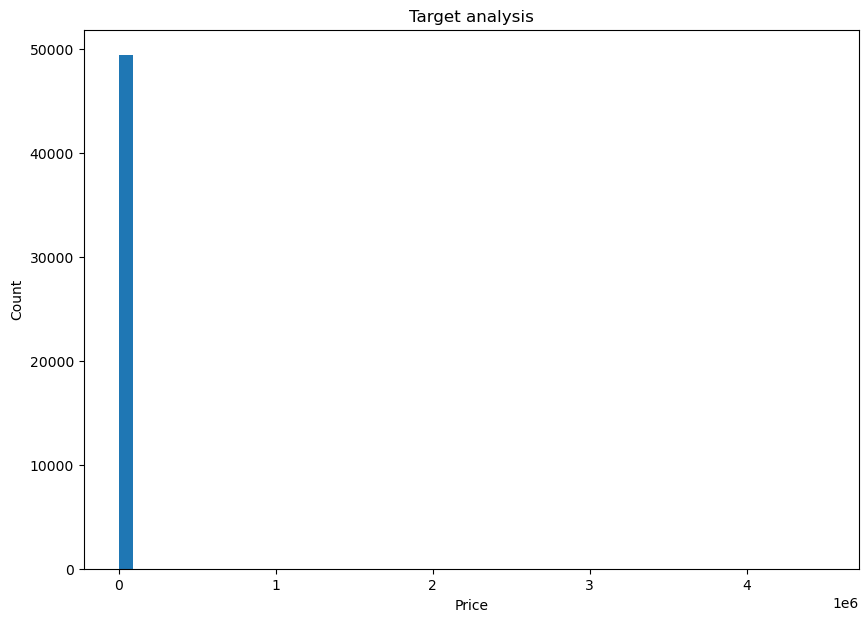

In [558]:
plt.figure(figsize=(10, 7))
plt.hist(data['price'], bins=50)
plt.title("Target analysis")
plt.xlabel("Price")
plt.ylabel("Count")
plt.show()

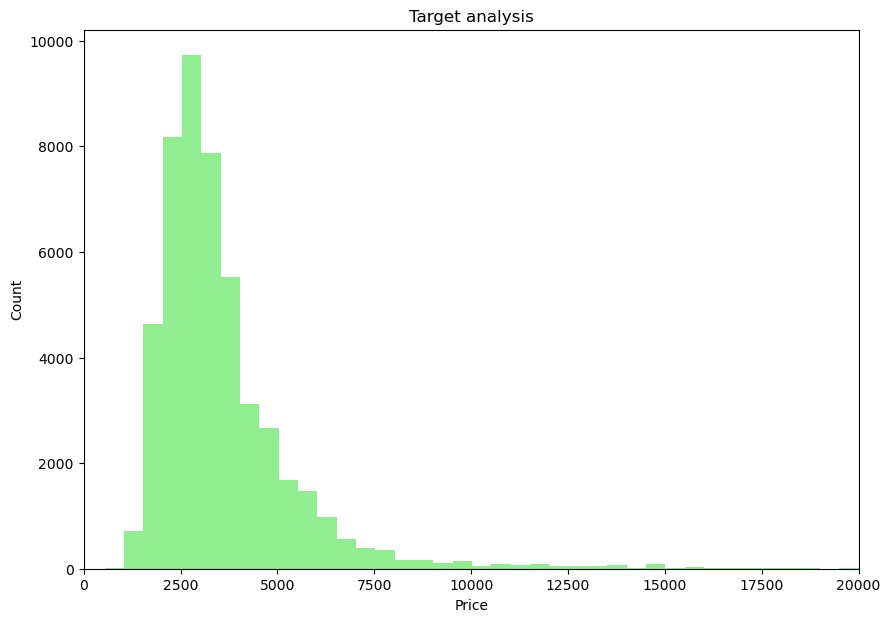

In [559]:
plt.figure(figsize=(10, 7))
plt.hist(data['price'], bins=9000, color='lightgreen')
plt.xlim(0, 20000)
plt.title("Target analysis")
plt.xlabel("Price")
plt.ylabel("Count")
plt.show()

При построении, видно, что большинство квартир сконцентрированы в диапазоне примерно от 2000 до 8000, однако встречаются отдельные выбросы с ценами значительно выше среднего

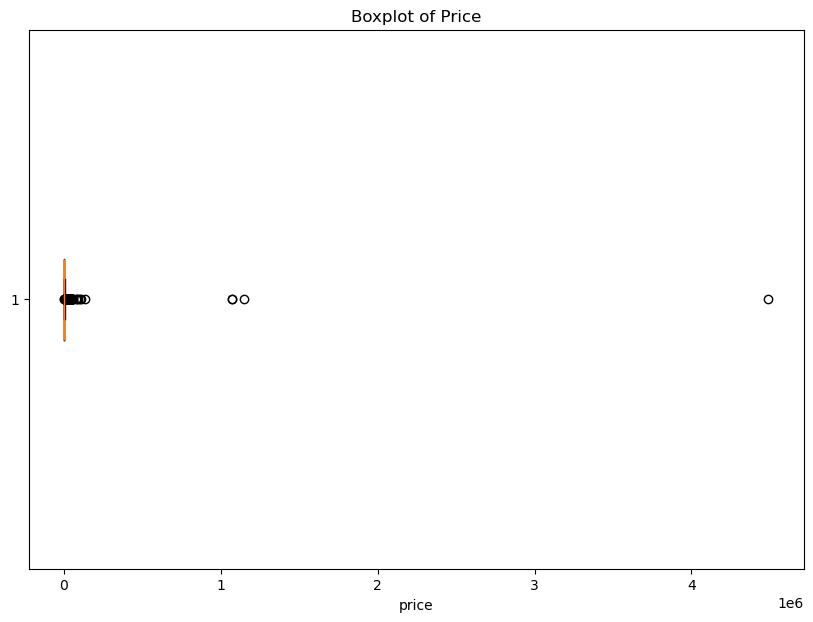

In [561]:
plt.figure(figsize = (10, 7))
           
plt.boxplot(data['price'], vert=False)

plt.title("Boxplot of Price")
plt.xlabel("price")

plt.show()

На данном графике нет видимых деталей, так как присутствуют выбросы и Boxplot масштабируется так, чтобы показать все данные, включая выбросы. Необходимо удлаить выбросы (отфильтровать по перцентилям 1% и 99%)

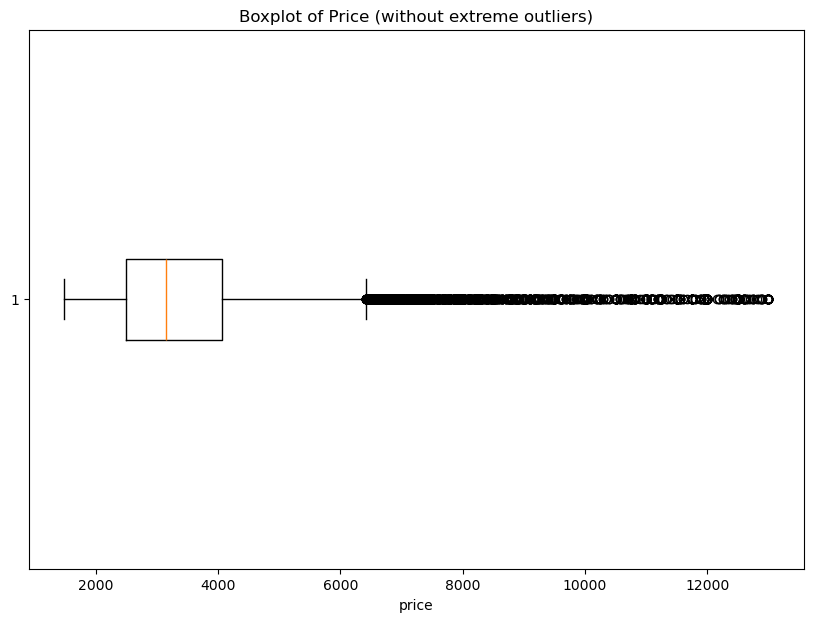

In [563]:
lower_limit = data['price'].quantile(0.01)
upper_limit = data['price'].quantile(0.99)

data = data[(data['price'] >= lower_limit) & (data['price'] <= upper_limit)]

plt.figure(figsize = (10, 7))
plt.boxplot(data['price'], vert=False)
plt.title("Boxplot of Price (without extreme outliers)")
plt.xlabel("price")
plt.show()

После удаления крайних 1% и 99% наблюдений, видно, что медианная цена аренды составляет около 3150, а большинство квартир находится в диапазоне 2500–4000

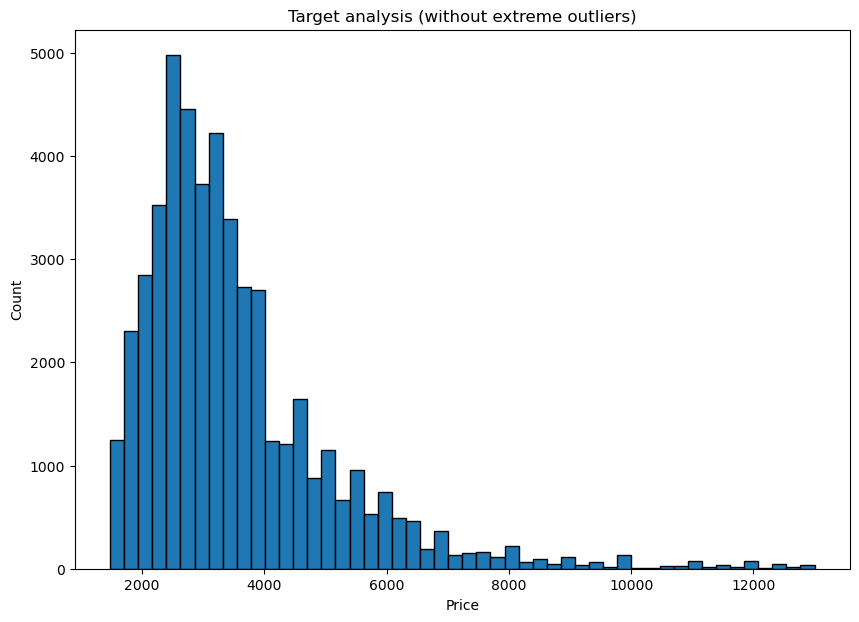

In [565]:
plt.figure(figsize=(10, 7))
plt.hist(data['price'], bins=50, edgecolor='black')
plt.title("Target analysis (without extreme outliers)")
plt.xlabel("Price")
plt.ylabel("Count")
plt.show()

Первоначальная гистограмма была сжата из-за сильных выбросов, поэтому пришлось использовать ограничение xlim(0, 20000)
После удаления крайних 1% и 99% значений распределение стало наглядным:
основная масса квартир сконцентрирована в диапазоне 2000–6000,
наблюдается асимметрия вправо, что указывает на наличие небольшой дорогих предложений.
Таким образом, очищенные данные лучше отражают общие закономерности и более пригодны для построения моделей.

### Characteristics Analysis

In [568]:
data['interest_level'].info()

<class 'pandas.core.series.Series'>
Index: 48379 entries, 0 to 49351
Series name: interest_level
Non-Null Count  Dtype 
--------------  ----- 
48379 non-null  object
dtypes: object(1)
memory usage: 755.9+ KB


Тип колонки 'interest_level' object

In [570]:
data['interest_level'].value_counts()

interest_level
low       33697
medium    11116
high       3566
Name: count, dtype: int64

In [571]:
print(data['interest_level'].unique())

['medium' 'low' 'high']


In [572]:
mapping = {"low": 0, "medium": 1, "high": 2}

data["interest_level"] = data["interest_level"].apply(
    lambda x: mapping[x] if isinstance(x, str) else x
)
data

,bathrooms,bedrooms,interest_level,price
0,1.0,1,1,2400
1,1.0,2,0,3800
2,1.0,2,1,3495
3,1.5,3,1,3000
4,1.0,0,0,2795
...,...,...,...,...
49347,1.0,3,0,2800
49348,1.0,2,1,2395
49349,1.0,1,1,1850
49350,1.0,2,1,4195


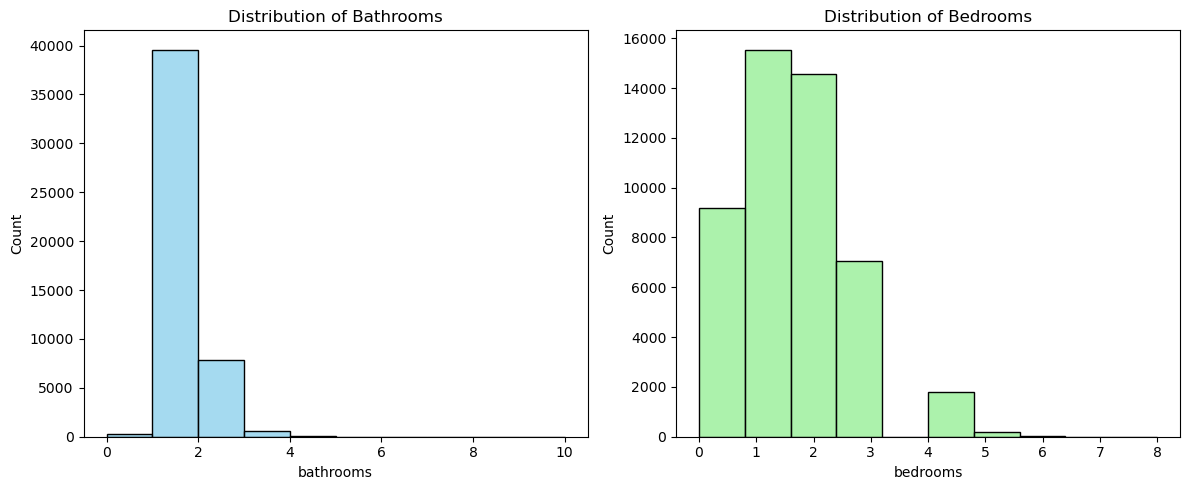

In [573]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.histplot(data=data, x='bathrooms', bins=10, color='skyblue', ax=axes[0])
axes[0].set_title('Distribution of Bathrooms')

sns.histplot(data=data, x='bedrooms', bins=10, color='lightgreen', ax=axes[1])
axes[1].set_title('Distribution of Bedrooms')

plt.tight_layout()
plt.show()

В данных присутствуют выбросы: некоторые квартиры имеют до 10 ванных комнат и 8 спален

### Complex analysis

In [576]:
data.corr()

,bathrooms,bedrooms,interest_level,price
bathrooms,1.000000,0.517574,-0.063635,0.671943
bedrooms,0.517574,1.000000,0.050654,0.545948
interest_level,-0.063635,0.050654,1.000000,-0.200111
price,0.671943,0.545948,-0.200111,1.000000


<Axes: >

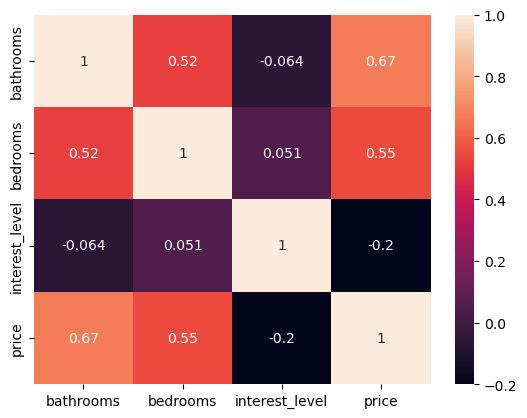

In [577]:
sns.heatmap(data.corr(), annot=True)

Согласно тепловой карте корреляций, признаки bathrooms и bedrooms умеренно коррелируют между собой (r = 0.52).
Оба признака слабо положительно связаны с целевой переменной price (r ≈ 0.05–0.07).
Это означает, что количество комнат немного влияет на цену, но решающими факторами, вероятно, являются другие признаки.

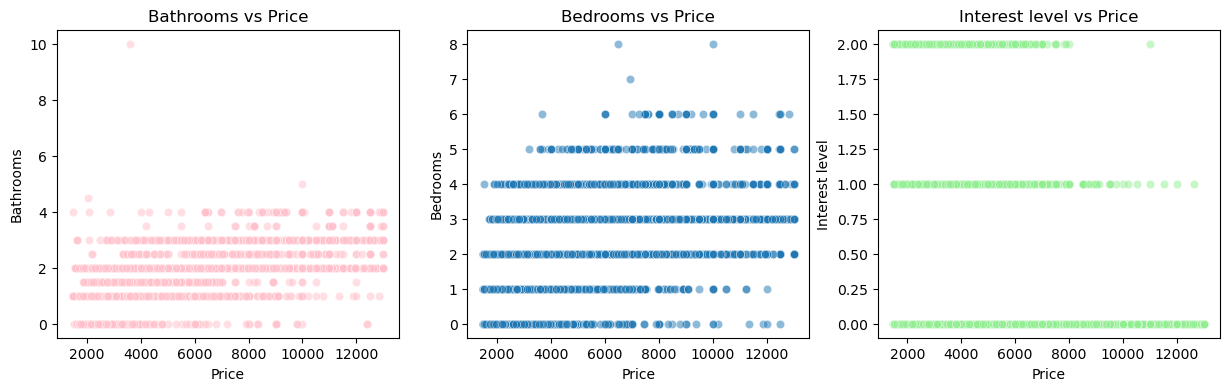

In [579]:
plt.figure(figsize=(15, 4))

plt.subplot(1, 3, 1)
sns.scatterplot(data=data, x='price', y='bathrooms', alpha=0.5, color='pink')
plt.title('Bathrooms vs Price')
plt.xlabel('Price')
plt.ylabel('Bathrooms')

plt.subplot(1, 3, 2)
sns.scatterplot(data=data, x='price', y='bedrooms', alpha=0.5)
plt.title('Bedrooms vs Price')
plt.xlabel('Price')
plt.ylabel('Bedrooms')

plt.subplot(1, 3, 3)
sns.scatterplot(data=data, x='price', y='interest_level', alpha=0.5, color='lightgreen')
plt.title('Interest level vs Price')
plt.xlabel('Price')
plt.ylabel('Interest level')

plt.show()

На основании диаграмм рассеяния можно сказать, что количество спален и ванных положительно связано с ценой, а интерес пользователей — отрицательно.

### 4. Creating Features

In [582]:
data['bathrooms_squared'] = data['bathrooms'] ** 2
data['bedrooms_squared'] = data['bedrooms'] ** 2
data['interest_level_squared'] = data['interest_level'] ** 2

In [583]:
corr_matrix = data[['bathrooms', 'bedrooms', 'interest_level',
                    'bathrooms_squared', 'bedrooms_squared', 'interest_level_squared',
                    'price']].corr()

corr_matrix

,bathrooms,bedrooms,interest_level,bathrooms_squared,bedrooms_squared,interest_level_squared,price
bathrooms,1.000000,0.517574,-0.063635,0.956023,0.548760,-0.059410,0.671943
bedrooms,0.517574,1.000000,0.050654,0.478817,0.928277,0.039511,0.545948
interest_level,-0.063635,0.050654,1.000000,-0.068558,0.046340,0.944013,-0.200111
bathrooms_squared,0.956023,0.478817,-0.068558,1.000000,0.522227,-0.062240,0.648486
bedrooms_squared,0.548760,0.928277,0.046340,0.522227,1.000000,0.035718,0.543406
interest_level_squared,-0.059410,0.039511,0.944013,-0.062240,0.035718,1.000000,-0.182672
price,0.671943,0.545948,-0.200111,0.648486,0.543406,-0.182672,1.000000


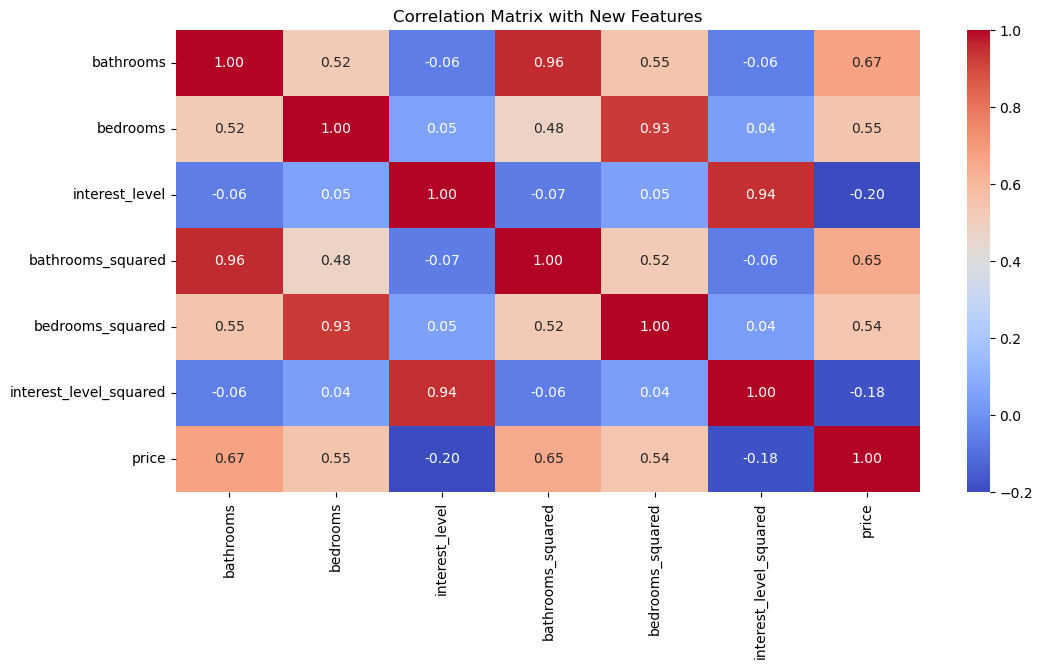

In [584]:
plt.figure(figsize=(12, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix with New Features')
plt.show()

После добавления квадратичных признаков видно, что их корреляция с целевой переменной price
не стала выше, чем у исходных признаков.
Это говорит о том, что связь между количеством ванных и спален и ценой в данной выборке в целом линейная,
и добавление степенных признаков не даёт значительного улучшения.

Таким образом, для дальнейшего обучения я буду использовать базовые признаки без квадратов.

In [586]:
test_sample = pd.read_json("./data/test.json", orient="columns")[["bathrooms", "bedrooms", "price"]]
train_sample = pd.read_json("./data/train.json", orient="columns")[["bathrooms", "bedrooms", "price"]]

In [704]:
quan_1, quan_99 = test_sample["price"].quantile(q=[0.01, 0.99])
test_sample = test_sample[(quan_1 < test_sample["price"]) & (quan_99 > test_sample["price"])]

test_sample.reset_index(drop=True, inplace=True)

test_sample = test_sample[(test_sample['bathrooms'] >= 0) & (test_sample['bathrooms'] <= 10)]

test_sample

,bathrooms,bedrooms,price
0,1.0,1,2950
1,1.0,2,2850
2,1.0,0,2295
3,1.0,2,2900
4,1.0,1,3254
...,...,...,...
73122,1.0,1,1700
73123,1.0,2,4195
73124,1.0,0,2400
73125,2.0,2,6895


In [706]:
quan_1, quan_99 = train_sample["price"].quantile(q=[0.01, 0.99])
train_sample = train_sample[(quan_1 < train_sample["price"]) & (quan_99 > train_sample["price"])]

train_sample.reset_index(drop=True, inplace=True)

train_sample

,bathrooms,bedrooms,price
0,1.0,1,2400
1,1.0,2,3800
2,1.0,2,3495
3,1.5,3,3000
4,1.0,0,2795
...,...,...,...
47246,1.0,3,2800
47247,1.0,2,2395
47248,1.0,1,1850
47249,1.0,2,4195


In [708]:
X_train = train_sample[['bathrooms', 'bedrooms']]
y_train = train_sample['price']

X_test = test_sample[['bathrooms', 'bedrooms']]
y_test = test_sample['price']


In [710]:
poly = PolynomialFeatures(degree=10, include_bias=False)

X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

### 5. Train 3 models: linear regression, decision tree and naive model. 

In [713]:
result_MAE = pd.DataFrame(columns = ['model', 'train', 'test'])
result_RMSE = pd.DataFrame(columns = ['model', 'train', 'test'])

In [715]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [717]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

In [719]:
lr = LinearRegression()

lr.fit(X_train_poly, y_train)

y_train_pred = lr.predict(X_train_poly)
y_test_pred = lr.predict(X_test_poly)

mae_train = mean_absolute_error(y_train, y_train_pred)
mae_test = mean_absolute_error(y_test, y_test_pred)

rmse_train = np.sqrt(mean_squared_error(y_train, y_train_pred))
rmse_test = np.sqrt(mean_squared_error(y_test, y_test_pred))

result_MAE.loc[len(result_MAE)] = ['linear_regression', mae_train, mae_test]
result_RMSE.loc[len(result_RMSE)] = ['linear_regression', rmse_train, rmse_test]

In [721]:
from sklearn.tree import DecisionTreeRegressor

In [723]:
dt = DecisionTreeRegressor(random_state=21)

dt.fit(X_train_poly, y_train)

y_train_pred = dt.predict(X_train_poly)
y_test_pred = dt.predict(X_test_poly)

mae_train = mean_absolute_error(y_train, y_train_pred)
mae_test = mean_absolute_error(y_test, y_test_pred)

rmse_train = np.sqrt(mean_squared_error(y_train, y_train_pred))
rmse_test = np.sqrt(mean_squared_error(y_test, y_test_pred))
            
result_MAE.loc[len(result_MAE)] = ['decision_tree', mae_train, mae_test]
result_RMSE.loc[len(result_RMSE)] = ['decision_tree', rmse_train, rmse_test]

In [725]:
mean_price = y_train.mean()
y_train_pred_mean = np.full_like(y_train, mean_price)
y_test_pred_mean = np.full_like(y_test, mean_price)

mae_train = mean_absolute_error(y_train, y_train_pred_mean)
mae_test = mean_absolute_error(y_test, y_test_pred_mean)
rmse_train = np.sqrt(mean_squared_error(y_train, y_train_pred_mean))
rmse_test = np.sqrt(mean_squared_error(y_test, y_test_pred_mean))

result_MAE.loc[len(result_MAE)] = ['naive_mean', mae_train, mae_test]
result_RMSE.loc[len(result_RMSE)] = ['naive_mean', rmse_train, rmse_test]

median_price = y_train.median()
y_train_pred_median = np.full_like(y_train, median_price)
y_test_pred_median = np.full_like(y_test, median_price)

mae_train = mean_absolute_error(y_train, y_train_pred_median)
mae_test = mean_absolute_error(y_test, y_test_pred_median)
rmse_train = np.sqrt(mean_squared_error(y_train, y_train_pred_median))
rmse_test = np.sqrt(mean_squared_error(y_test, y_test_pred_median))

result_MAE.loc[len(result_MAE)] = ['naive_median', mae_train, mae_test]
result_RMSE.loc[len(result_RMSE)] = ['naive_median', rmse_train, rmse_test]

In [727]:
result_MAE

,model,train,test
0,linear_regression,710.265362,3583.611003
1,decision_tree,710.265362,761.790921
2,naive_mean,1042.289708,1117.381569
3,naive_median,1003.609193,1078.660235


In [729]:
result_RMSE

,model,train,test
0,linear_regression,969.255355,512791.631172
1,decision_tree,969.255355,1094.371618
2,naive_mean,1380.279880,1573.925463
3,naive_median,1419.476165,1617.920212


In [733]:
test_sample['bathrooms'].value_counts().sort_index()

bathrooms
0.0      447
1.0    58882
1.5      997
2.0    11450
2.5      371
3.0      837
3.5       41
4.0       96
5.0        3
6.0        2
6.5        1
Name: count, dtype: int64

In [735]:
train_sample['price'].describe()
test_sample['price'].describe()

count    73127.000000
mean      3527.621521
std       1573.245577
min       1496.000000
25%       2500.000000
50%       3150.000000
75%       4075.000000
max      12995.000000
Name: price, dtype: float64